### Build a chat bot with LangGraph (Graph API)

In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages


In [2]:
class state(TypedDict):
    messages:Annotated[list,add_messages]



In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("What is the capital of France?")

AIMessage(content='<think>\nOkay, so the user is asking for the capital of France. Let me start by recalling what I know about France. I remember that France is a country in Western Europe. Capitals are usually the main cities where the government is located. I think the capital might be Paris, but I should double-check to be sure.\n\nWait, isn\'t Paris also known as the "City of Light"? Yeah, that rings a bell. I\'ve heard Paris mentioned in many contexts, like art, fashion, and tourism. It\'s home to famous landmarks such as the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral. That makes me more confident that Paris is indeed the capital.\n\nLet me think if there\'s any other city that could be confused with the capital. Lyon is another major city in France, known for its cuisine and historical sites, but I don\'t think it\'s the capital. Marseille is a big port city, and Nice is on the French Riviera. None of these seem to be the capital. \n\nI should also consider if ther

In [5]:
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(state)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph=graph_builder.compile()

In [7]:
response=graph.invoke({"messages":"hi"})


In [8]:
response["messages"][-1].content

'<think>\nOkay, the user said "hi". That\'s a greeting. I should respond politely. Maybe say hello back and ask how I can help. Keep it friendly and open-ended. Let them know I\'m here for any questions or tasks they might have. Make sure the tone is positive and approachable. Alright, that should cover it.\n</think>\n\nHello! How can I assist you today? 😊'

In [9]:
for event in graph.stream({"messages":"hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user asked how I'm doing. I need to respond in a friendly and approachable way. Since I'm an AI, I don't have real feelings, but I should express that I'm ready to help and have a positive attitude. At the same time, I need to keep it concise and not too long. Maybe add an emoji to make it friendlier. Let me make sure I don't overcomplicate it and keep the tone warm and inviting.
</think>

Hello! I'm doing well, thank you! 😊 How can I assist you today?


### ChatBot with Tool

In [10]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=1)
tool.invoke("What is langchain?")


{'query': 'What is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain? - AWS',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and 

In [11]:
def multiply(a:int,b:int)->int:
    """
    Multiply a and b

    args:
        a: first number
        b: second number

    returns:
        int: output of int
    """
    return a*b

In [12]:
tools=[tool,multiply]
llm_with_tools=llm.bind_tools(tools)

In [13]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D823403E00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D82363C980>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real

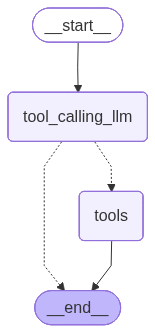

In [14]:
## state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
#define state
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm) 
builder.add_node("tools", ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools",END)

graph=builder.compile()

display(graph)

In [15]:
response=graph.invoke({"messages": "what is the recent ai news?"})
response["messages"][-1].content


'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.csoonline.com/article/4180316/ai-may-finally-unlock-the-cyber-budgets-cisos-have-wanted-for-years.html", "title": "AI may finally unlock the cyber budgets CISOs have wanted for years - csoonline.com", "score": 0.6739866, "published_date": "Wed, 03 Jun 2026 00:00:00 GMT", "content": "Jun 2, 2026 8 mins\\n news analysis\\n\\n  ### What happens when China’s AI catches up to Mythos?\\n\\n  May 13, 2026 6 mins\\n feature\\n\\n  ### Poisoned truth: The quiet security threat inside enterprise AI\\n\\n  May 6, 2026 10 mins\\n news\\n\\n  ### CISA pushes critical infrastructure operators to prepare to work in isolation\\n\\n  May 5, 2026 6 mins\\n news\\n\\n  ### Anthropic Mythos spurs White House to weigh pre-release reviews for high-risk AI models\\n\\n  May 4, 2026 4 mins\\n news\\n\\n  ### New US House privacy bills raise hard questions about enterprise data collection\\n\\n  Ap

In [16]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jssxxwtsg)
 Call ID: jssxxwtsg
  Args:
    query: AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.csoonline.com/article/4180316/ai-may-finally-unlock-the-cyber-budgets-cisos-have-wanted-for-years.html", "title": "AI may finally unlock the cyber budgets CISOs have wanted for years - csoonline.com", "score": 0.6739866, "published_date": "Wed, 03 Jun 2026 00:00:00 GMT", "content": "Jun 2, 2026 8 mins\n news analysis\n\n  ### What happens when China’s AI catches up to Mythos?\n\n  May 13, 2026 6 mins\n feature\n\n  ### Poisoned truth: The 

In [17]:
response = graph.invoke({"messages": "what is 6 multiplied by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 6 multiplied by 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (xkhw70egm)
 Call ID: xkhw70egm
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: multiply

42


### ReAct Agent Architecture

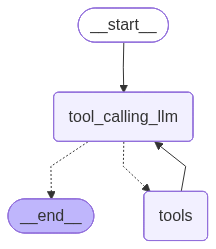

In [18]:
# state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
# define state


def tool_calling_llm(state: state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(graph)

In [19]:
response = graph.invoke({"messages": "give me recent ai news and then multiply 6 by 7"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news and then multiply 6 by 7
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pzg8k6t1j)
 Call ID: pzg8k6t1j
  Args:
    include_images: True
    query: AI news
    search_depth: advanced
    time_range: week
  multiply (vh84x3xeb)
 Call ID: vh84x3xeb
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": ["https://www.artificialintelligence-news.com/wp-content/uploads/2025/01/New-site-SEO-social-banner-1200x600-1.jpg", "https://datahubanalytics.com/wp-content/uploads/2025/03/ai-news-dha-1170x570.webp", "https://image.cnbcfm.com/api/v1/image/105564742-1541761951205chinesenewsanchor.png?v=1541762084&w=1920&h=1080", "https://aiworld-summit.com/wp-content/uploads/2023/12/AI-NEWS-logo

### Adding Memory in Agentic Graph

In [20]:
response=graph.invoke({"messages":"hello my name is a luffy?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello my name is a luffy?
================================== Ai Message ==================================

Hello Luffy! Nice to meet you! 😊 How can I assist you today?


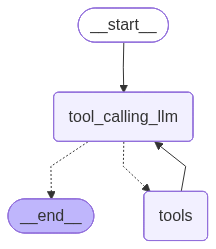

In [21]:
# state graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
# define state


def tool_calling_llm(state: state):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer=memory_saver)

display(graph)

In [22]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"hello my name is luffy"},config=config)
response

{'messages': [HumanMessage(content='hello my name is luffy', additional_kwargs={}, response_metadata={}, id='9b1257e5-b097-4361-9b78-35eae4320135'),
  AIMessage(content='Hello, Luffy! Nice to meet you! How can I help you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "hello my name is luffy." Let me think about how to respond.\n\nFirst, I need to acknowledge their greeting. Since they introduced themselves as Luffy, I should use their name in the response to make it friendly. Maybe say something like, "Hello, Luffy! Nice to meet you!" That sounds welcoming.\n\nNow, I should check if there\'s anything else they need. They might want to ask a question or get help with something. But the current message is just an introduction, so I should prompt them to let me know how I can assist. Adding a follow-up like, "How can I help you today?" would be good.\n\nWait, are there any tools I need to use here? The user didn\'t ask a specific question that requires a function c

In [23]:
response["messages"][-1].content

'Hello, Luffy! Nice to meet you! How can I help you today?'

In [24]:
response=graph.invoke({"messages":"hey what was my name?"}, config=config)
response["messages"][-1].content

'Your name is Luffy! 😊 How can I assist you today, Luffy?'